# PriceAction Ensemble — Backtest & Signal Filtering

6-kernel price-geometry model (FVG, Sweep, Pin Bar, Engulfing, BOS, Inside Bar).
Uses OHLCV + ATR only — orthogonal to oscillator-based models.

**Goals:**
1. Baseline PA performance with default params
2. Reduce over-trading via signal threshold + decay tuning
3. Compare best PA variant against BTC buy-and-hold and S&P buy-and-hold
4. GO/NO-GO verdict

In [1]:
# ── Cell 1: Setup & Imports ──────────────────────────────────────────────
import sys, types
sys.path.insert(0, '../src')

# Create 'app' namespace alias (regime module uses app.regime.* imports)
import importlib
app = types.ModuleType('app')
app.__path__ = ['../src/libs', '../src/apps']
sys.modules['app'] = app

try:
    import hmmlearn
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hmmlearn', '-q'])

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import yaml
import warnings
from datetime import datetime, timezone
from types import SimpleNamespace
from binance.um_futures import UMFutures

# Project imports
from libs.regime.orchestrator import RegimeOrchestrator
from libs.models.registry import ModelRegistry
from libs.models.blender.ensemble import RegimeEnsembleBlender, REGIME_TO_GROUP
from libs.contracts.signal import ScoringOutput
from libs.optim_utils.scoring_feature_pipeline import build_scoring_feature_df
from libs.optim_utils.scoring import (
    compute_sharpe, compute_max_drawdown, compute_returns, compute_win_rate,
    split_temporal, BARS_PER_YEAR,
)

# PA model imports
from libs.models.price_action.model import PriceActionModel
from libs.models.price_action.batch import _batch_price_action
from libs.models.price_action.kernels.fvg import fvg_score
from libs.models.price_action.kernels.sweep import sweep_score
from libs.models.price_action.kernels.pin_bar import pin_bar_score
from libs.models.price_action.kernels.engulfing import engulfing_score
from libs.models.price_action.kernels.bos import bos_score
from libs.models.price_action.kernels.inside_bar import inside_bar_score

import libs.models  # noqa: auto_discover

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

COST_BPS = 10.0
GROUPS = ['CLEAN_TREND', 'VOLATILE_TREND', 'QUIET_RANGE', 'SQUEEZE', 'CHOPPY']

client = UMFutures()
print('Setup complete')

Setup complete


In [2]:
# ── Cell 2: Fetch OHLCV + Build Features + Regimes ────────────────────────
_ALL_COLS = [
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
    'quote_volume', 'trades', 'taker_buy_base', 'taker_buy_quote', 'ignore'
]

def fetch_ohlcv(symbol, interval, start_date, end_date):
    start_ms = int(datetime.strptime(start_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    end_ms = int(datetime.strptime(end_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    all_rows = []
    cursor = start_ms
    while cursor < end_ms:
        raw = client.klines(symbol, interval, startTime=cursor, endTime=end_ms, limit=1500)
        if not raw:
            break
        all_rows.extend(raw)
        cursor = int(raw[-1][6]) + 1
        if len(raw) < 1500:
            break
        time.sleep(0.15)
    df = pd.DataFrame(all_rows, columns=_ALL_COLS)
    for c in ['open','high','low','close','volume']:
        df[c] = df[c].astype(float)
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    print(f'{symbol} {interval}: {len(df)} bars  [{df.timestamp.iloc[0]} \u2192 {df.timestamp.iloc[-1]}]')
    return df

START, END = '2025-12-01', '2026-05-31'
btc_ohlcv = fetch_ohlcv('BTCUSDT', '1h', START, END)

# Build features
import os
if os.path.basename(os.getcwd()) == 'research':
    os.chdir('../')
from libs.common.config import ConfigManager
ConfigManager._instance = None

btc_features = build_scoring_feature_df(btc_ohlcv, 'BTCUSDT', '1h')
print(f'BTC features: {btc_features.shape}')

# Regime labels
btc_orch = RegimeOrchestrator.create('BTCUSDT', '1h')
btc_regime_df = btc_orch.analyze_series(btc_ohlcv)
for col in ['regime', 'p_trending', 'vol_percentile', 'changepoint_prob']:
    if col in btc_regime_df.columns:
        btc_features[col] = btc_regime_df[col].values
btc_features['regime_group'] = btc_features['regime'].map(REGIME_TO_GROUP)

# Forward returns
for h in [1, 4, 12]:
    btc_features[f'fwd_ret_{h}'] = btc_features['close'].pct_change(h).shift(-h)

# BTC buy-and-hold return per bar
btc_features['bh_ret'] = btc_features['close'].pct_change()

print(f'Regime distribution:')
for grp in GROUPS:
    n = (btc_features['regime_group'] == grp).sum()
    print(f'  {grp:18s}: {n:5d} ({n/len(btc_features)*100:.1f}%)')

# Also run Momentum as baseline comparison
mom_cls = ModelRegistry.get('Momentum')
with open('configs/models.yaml') as f:
    models_yaml = yaml.safe_load(f)
mom_params = models_yaml['models']['assets']['BTCUSDT']['timeframes']['1h'].get('Momentum', {}).get('params', {})
mom_model = mom_cls(mom_params or {})
btc_features['edge_Momentum'] = mom_model.batch_evaluate(btc_features).astype(float)
print(f'\nMomentum signals: long={( btc_features["edge_Momentum"] > 0).sum()}, short={( btc_features["edge_Momentum"] < 0).sum()}')

BTCUSDT 1h: 4345 bars  [2025-12-01 00:00:00+00:00 → 2026-05-31 00:00:00+00:00]
BTC features: (4345, 43)


Regime distribution:
  CLEAN_TREND       :   228 (5.2%)
  VOLATILE_TREND    :   132 (3.0%)
  QUIET_RANGE       :  1090 (25.1%)
  SQUEEZE           :  1743 (40.1%)
  CHOPPY            :  1152 (26.5%)

Momentum signals: long=181, short=396


In [3]:
# ── Cell 3: Evaluate Signal Helper + Benchmark Setup ──────────────────────

def evaluate_signal(df, signal_col, horizon=1, cost_bps=10.0):
    """Evaluate a signal column against forward returns."""
    fwd_col = f'fwd_ret_{horizon}'
    mask = df[signal_col].notna() & df[fwd_col].notna() & (df[signal_col] != 0)
    sub = df[mask].copy()
    if len(sub) == 0:
        return {'sharpe': 0.0, 'hit_rate': 0.0, 'max_dd': 0.0, 'cum_ret': 0.0, 'n_trades': 0}

    direction = np.sign(sub[signal_col].values)
    fwd_ret = sub[fwd_col].values
    strat_ret = direction * fwd_ret

    dir_changes = np.diff(np.concatenate([[0.0], direction]))
    trade_mask = dir_changes != 0
    trade_costs = np.abs(dir_changes) * (cost_bps / 10_000.0)
    strat_ret -= trade_costs[:len(strat_ret)]

    cum = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max

    ann_factor = BARS_PER_YEAR.get('1h', 8760)
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(ann_factor)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)

    return {
        'sharpe': sharpe,
        'hit_rate': hit_rate,
        'max_dd': float(np.min(dd)),
        'cum_ret': float(cum[-1] - 1.0),
        'n_trades': int(trade_mask.sum()),
    }


def evaluate_signal_with_threshold(df, signal_col, threshold, horizon=1, cost_bps=10.0):
    """Evaluate signal with a minimum |edge| threshold — only trade when |edge| > threshold."""
    fwd_col = f'fwd_ret_{horizon}'
    mask = df[signal_col].notna() & df[fwd_col].notna() & (df[signal_col].abs() > threshold)
    sub = df[mask].copy()
    if len(sub) == 0:
        return {'sharpe': 0.0, 'hit_rate': 0.0, 'max_dd': 0.0, 'cum_ret': 0.0, 'n_trades': 0, 'active_bars': 0}

    direction = np.sign(sub[signal_col].values)
    fwd_ret = sub[fwd_col].values
    strat_ret = direction * fwd_ret

    dir_changes = np.diff(np.concatenate([[0.0], direction]))
    trade_mask = dir_changes != 0
    trade_costs = np.abs(dir_changes) * (cost_bps / 10_000.0)
    strat_ret -= trade_costs[:len(strat_ret)]

    cum = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max

    ann_factor = BARS_PER_YEAR.get('1h', 8760)
    sharpe = (np.mean(strat_ret) / np.std(strat_ret) * math.sqrt(ann_factor)) if np.std(strat_ret) > 0 else 0.0
    hit_rate = np.mean(strat_ret > 0)

    return {
        'sharpe': sharpe,
        'hit_rate': hit_rate,
        'max_dd': float(np.min(dd)),
        'cum_ret': float(cum[-1] - 1.0),
        'n_trades': int(trade_mask.sum()),
        'active_bars': len(sub),
    }


# BTC buy-and-hold benchmark
bh_valid = btc_features['bh_ret'].dropna()
bh_cum = np.cumprod(1 + bh_valid.values)
bh_cum_ret = bh_cum[-1] - 1.0
bh_sharpe = (np.mean(bh_valid.values) / np.std(bh_valid.values) * math.sqrt(8760)) if np.std(bh_valid.values) > 0 else 0.0
bh_dd = np.min((bh_cum - np.maximum.accumulate(bh_cum)) / np.maximum.accumulate(bh_cum))

# S&P 500 buy-and-hold approximation (annualized ~10%, hourly = 10% / 8760)
# Use ~10% annual return, ~15% annual vol as benchmark
sp_annual_return = 0.10
sp_annual_vol = 0.15
sp_hourly_return = sp_annual_return / 8760
n_hours = len(bh_valid)
sp_cum_ret = (1 + sp_hourly_return) ** n_hours - 1.0
sp_sharpe = sp_annual_return / sp_annual_vol

print(f'Benchmarks ({n_hours} bars / {n_hours/24:.0f} days):')
print(f'  BTC Buy & Hold:  Sharpe={bh_sharpe:+.2f}  CumRet={bh_cum_ret:+.1%}  MaxDD={bh_dd:.1%}')
print(f'  S&P 500 B&H:    Sharpe={sp_sharpe:+.2f}  CumRet={sp_cum_ret:+.1%}  (annualized approx)')
print(f'\nBenchmark bar: PA must beat Sharpe {bh_sharpe:+.2f} (BTC B&H) or {sp_sharpe:+.2f} (S&P B&H)')

Benchmarks (4344 bars / 181 days):
  BTC Buy & Hold:  Sharpe=-0.50  CumRet=-14.9%  MaxDD=-35.6%
  S&P 500 B&H:    Sharpe=+0.67  CumRet=+5.1%  (annualized approx)

Benchmark bar: PA must beat Sharpe -0.50 (BTC B&H) or +0.67 (S&P B&H)


In [4]:
# ── Cell 4: PA Baseline (default params) ──────────────────────────────────
pa_model = PriceActionModel({})
pa_open = btc_features['open'].values.astype(np.float64)
pa_high = btc_features['high'].values.astype(np.float64)
pa_low = btc_features['low'].values.astype(np.float64)
pa_close = btc_features['close'].values.astype(np.float64)
pa_atr = btc_features['ATR'].values.astype(np.float64)

def run_pa_batch(params):
    """Run PA batch with given params, return edge array."""
    return _batch_price_action(
        pa_open, pa_high, pa_low, pa_close, pa_atr,
        int(params['swing_lookback']),
        float(params['fvg_atr_scale']),
        float(params['sweep_wick_scale']),
        float(params['pin_wick_body_ratio']),
        float(params['pin_wick_dominance']),
        float(params['pin_min_range_atr']),
        float(params['pin_strength_scale']),
        float(params['engulf_min_body_atr']),
        float(params['engulf_ratio_scale']),
        float(params['bos_displacement_scale']),
        float(params['ib_breakout_scale']),
        float(params['w_fvg']),
        float(params['w_sweep']),
        float(params['w_pin']),
        float(params['w_engulf']),
        float(params['w_bos']),
        float(params['w_inside']),
        float(params['confluence_scale']),
        int(params['confluence_min']),
        float(params['context_proximity_boost']),
        float(params['context_alignment_boost']),
        float(params['pattern_decay_rate']),
    )

# Baseline
btc_features['edge_PA_base'] = run_pa_batch(pa_model.params)

print('PA Baseline (default params, decay=0.3):')
r = evaluate_signal(btc_features, 'edge_PA_base', horizon=1, cost_bps=COST_BPS)
print(f'  Sharpe={r["sharpe"]:+.2f}  HR={r["hit_rate"]:.1%}  CumRet={r["cum_ret"]:+.1%}  DD={r["max_dd"]:.1%}  Trades={r["n_trades"]}')
print(f'  Active bars: {(btc_features["edge_PA_base"].abs() > 0).sum()} / {len(btc_features)}')

PA Baseline (default params, decay=0.3):
  Sharpe=-8.04  HR=43.6%  CumRet=-84.3%  DD=-84.8%  Trades=905
  Active bars: 4332 / 4345


EXPERIMENT 1: Signal Threshold Filtering (baseline PA, decay=0.3)
 Threshold   Sharpe      HR    CumRet    MaxDD  Trades  Active
------------------------------------------------------------
      0.00    -8.04   43.6%   -84.3%   -84.8%     905    4331
      0.01    -8.82   42.6%   -81.0%   -81.2%     865    3482
      0.02    -9.80   42.0%   -81.5%   -81.7%     845    3137
      0.03   -10.34   41.4%   -80.7%   -81.0%     821    2885
      0.05   -11.72   40.8%   -80.3%   -80.6%     775    2490
      0.07   -11.69   40.5%   -75.9%   -76.3%     707    2158
      0.10   -11.73   40.5%   -70.0%   -71.8%     623    1796
      0.15   -11.94   41.0%   -60.8%   -62.6%     466    1365
      0.20    -9.33   43.0%   -40.7%   -43.0%     316     963
      0.30   -13.34   44.7%   -29.1%   -28.8%     139     445
      0.50   -23.71   37.4%   -12.3%   -12.2%      52      99

Best threshold: 0.00 → Sharpe=-8.04


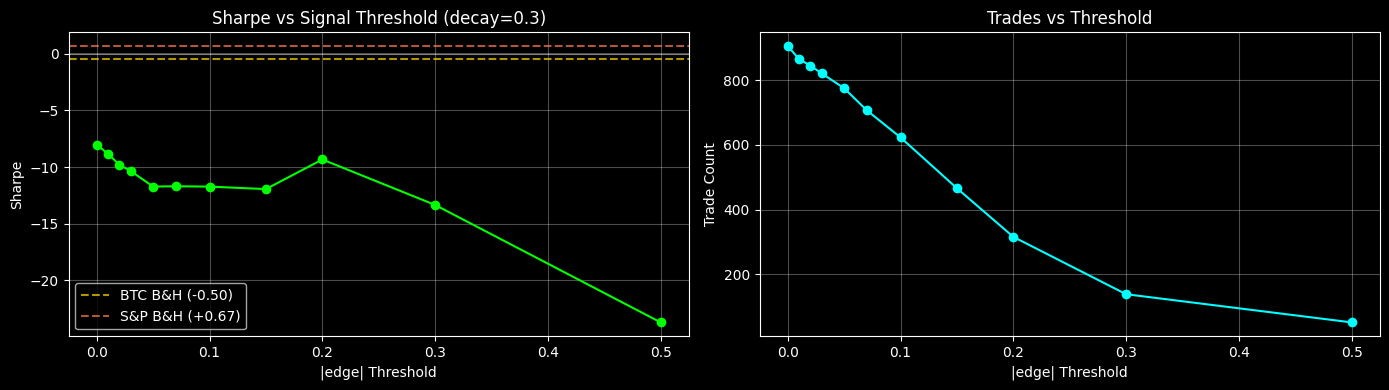

In [5]:
# ── Cell 5: Experiment 1 — Signal Threshold Sweep ─────────────────────────
# The baseline fires on 93.5% of bars due to pattern decay.
# Apply minimum |edge| thresholds to filter weak signals.

print('EXPERIMENT 1: Signal Threshold Filtering (baseline PA, decay=0.3)')
print(f'{"="*75}')
print(f'{"Threshold":>10s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s} {"MaxDD":>8s} {"Trades":>7s} {"Active":>7s}')
print(f'{"-"*60}')

threshold_results = []
for thr in [0.0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50]:
    r = evaluate_signal_with_threshold(btc_features, 'edge_PA_base', thr, horizon=1, cost_bps=COST_BPS)
    threshold_results.append({'threshold': thr, **r})
    print(f'{thr:10.2f} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["max_dd"]:8.1%} {r["n_trades"]:7d} {r["active_bars"]:7d}')

# Find best threshold
best_thr_result = max(threshold_results, key=lambda x: x['sharpe'])
print(f'\nBest threshold: {best_thr_result["threshold"]:.2f} → Sharpe={best_thr_result["sharpe"]:+.2f}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
thrs = [r['threshold'] for r in threshold_results]
sharpes = [r['sharpe'] for r in threshold_results]
trades = [r['n_trades'] for r in threshold_results]

ax1.plot(thrs, sharpes, 'o-', color='lime')
ax1.axhline(bh_sharpe, color='gold', linestyle='--', alpha=0.7, label=f'BTC B&H ({bh_sharpe:+.2f})')
ax1.axhline(sp_sharpe, color='coral', linestyle='--', alpha=0.7, label=f'S&P B&H ({sp_sharpe:+.2f})')
ax1.axhline(0, color='white', alpha=0.3)
ax1.set_xlabel('|edge| Threshold')
ax1.set_ylabel('Sharpe')
ax1.set_title('Sharpe vs Signal Threshold (decay=0.3)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(thrs, trades, 'o-', color='cyan')
ax2.set_xlabel('|edge| Threshold')
ax2.set_ylabel('Trade Count')
ax2.set_title('Trades vs Threshold')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

EXPERIMENT 2: Pattern Decay Rate Sweep
 Decay   Sharpe      HR    CumRet  Trades   Active    Pct
-------------------------------------------------------
  0.00   -15.47   38.1%   -86.8%    1001     2327  53.6%
  0.05    -8.72   43.0%   -86.6%     983     3231  74.4%
  0.10    -8.83   42.9%   -86.9%     977     3587  82.6%
  0.15    -8.82   42.9%   -86.9%     961     3713  85.5%
  0.20    -8.57   43.2%   -86.1%     941     3895  89.6%
  0.30    -8.04   43.6%   -84.3%     905     4063  93.5%
  0.50    -6.43   44.2%   -77.4%     803     4242  97.6%
  0.70    -5.00   45.7%   -68.9%     657     4315  99.3%

Best decay: 0.70 → Sharpe=-5.00 Active=4315 (99.3%)


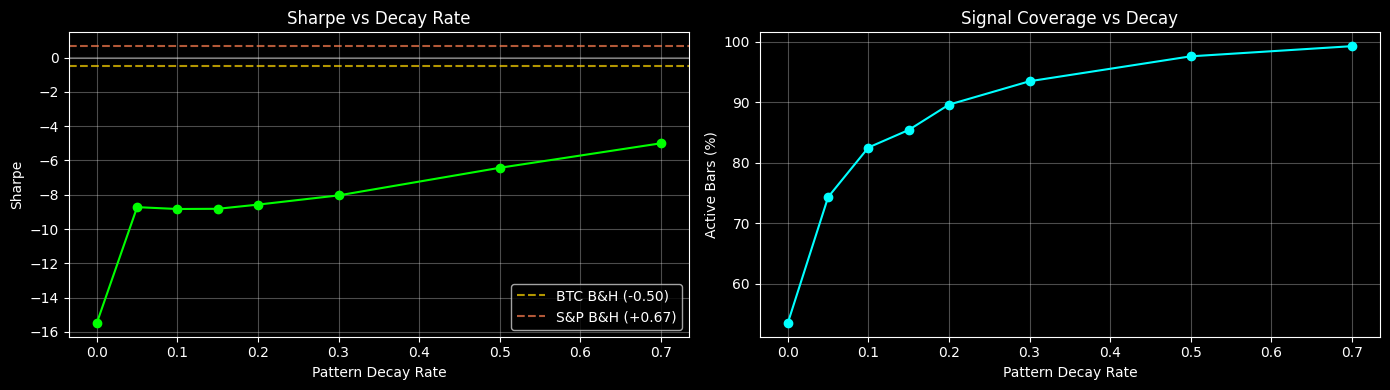

In [6]:
# ── Cell 6: Experiment 2 — Decay Rate Sweep ──────────────────────────────
# Pattern decay=0.3 makes signals persist. Try reducing/disabling decay.

print('EXPERIMENT 2: Pattern Decay Rate Sweep')
print(f'{"="*75}')
print(f'{"Decay":>6s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s} {"Trades":>7s} {"Active":>8s} {"Pct":>6s}')
print(f'{"-"*55}')

decay_results = []
for decay in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.70]:
    params = dict(pa_model.params)
    params['pattern_decay_rate'] = decay
    edge = run_pa_batch(params)
    col = f'edge_PA_d{int(decay*100):02d}'
    btc_features[col] = edge
    
    r = evaluate_signal(btc_features, col, horizon=1, cost_bps=COST_BPS)
    active = (btc_features[col].abs() > 0.001).sum()
    pct = active / len(btc_features) * 100
    decay_results.append({'decay': decay, 'col': col, 'active': active, 'pct': pct, **r})
    print(f'{decay:6.2f} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["n_trades"]:7d} {active:8d} {pct:5.1f}%')

best_decay_result = max(decay_results, key=lambda x: x['sharpe'])
print(f'\nBest decay: {best_decay_result["decay"]:.2f} → Sharpe={best_decay_result["sharpe"]:+.2f} Active={best_decay_result["active"]} ({best_decay_result["pct"]:.1f}%)')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
decays = [r['decay'] for r in decay_results]
sharpes = [r['sharpe'] for r in decay_results]
actives = [r['pct'] for r in decay_results]

ax1.plot(decays, sharpes, 'o-', color='lime')
ax1.axhline(bh_sharpe, color='gold', linestyle='--', alpha=0.7, label=f'BTC B&H ({bh_sharpe:+.2f})')
ax1.axhline(sp_sharpe, color='coral', linestyle='--', alpha=0.7, label=f'S&P B&H ({sp_sharpe:+.2f})')
ax1.axhline(0, color='white', alpha=0.3)
ax1.set_xlabel('Pattern Decay Rate')
ax1.set_ylabel('Sharpe')
ax1.set_title('Sharpe vs Decay Rate')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(decays, actives, 'o-', color='cyan')
ax2.set_xlabel('Pattern Decay Rate')
ax2.set_ylabel('Active Bars (%)')
ax2.set_title('Signal Coverage vs Decay')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ── Cell 7: Experiment 3 — Best Decay + Threshold Combo ──────────────────
# Combine the best decay with threshold filtering

best_decay = best_decay_result['decay']
best_decay_col = best_decay_result['col']

print(f'EXPERIMENT 3: Best Decay ({best_decay:.2f}) + Threshold Sweep')
print(f'{"="*75}')
print(f'{"Threshold":>10s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s} {"MaxDD":>8s} {"Trades":>7s} {"Active":>7s}')
print(f'{"-"*60}')

combo_results = []
for thr in [0.0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50]:
    r = evaluate_signal_with_threshold(btc_features, best_decay_col, thr, horizon=1, cost_bps=COST_BPS)
    combo_results.append({'threshold': thr, **r})
    print(f'{thr:10.2f} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["max_dd"]:8.1%} {r["n_trades"]:7d} {r["active_bars"]:7d}')

best_combo = max(combo_results, key=lambda x: x['sharpe'])
print(f'\nBest combo: decay={best_decay:.2f} + threshold={best_combo["threshold"]:.2f}')
print(f'  Sharpe={best_combo["sharpe"]:+.2f}  HR={best_combo["hit_rate"]:.1%}  Trades={best_combo["n_trades"]}  CumRet={best_combo["cum_ret"]:+.1%}')

EXPERIMENT 3: Best Decay (0.70) + Threshold Sweep
 Threshold   Sharpe      HR    CumRet    MaxDD  Trades  Active
------------------------------------------------------------
      0.00    -5.00   45.7%   -68.9%   -69.8%     657    4331
      0.01    -5.16   45.6%   -68.1%   -69.1%     623    4109
      0.02    -5.65   45.0%   -69.6%   -70.1%     589    3880
      0.03    -5.61   45.0%   -67.4%   -67.4%     563    3665
      0.05    -5.83   44.5%   -64.9%   -65.0%     527    3326
      0.07    -5.96   44.9%   -62.7%   -63.3%     479    3021
      0.10    -6.29   44.5%   -59.6%   -59.9%     429    2628
      0.15    -7.65   44.1%   -57.8%   -58.0%     358    2080
      0.20    -7.90   44.8%   -50.0%   -51.8%     294    1599
      0.30    -7.48   45.7%   -32.4%   -32.4%     184     919
      0.50   -12.54   45.9%   -18.6%   -18.6%      74     307

Best combo: decay=0.70 + threshold=0.00
  Sharpe=-5.00  HR=45.7%  Trades=657  CumRet=-68.9%


EXPERIMENT 4: Full Grid — Decay × Threshold

Top 10 combinations:
 Decay    Thr   Sharpe      HR    CumRet    MaxDD  Trades  Active
--------------------------------------------------------------
  0.30   0.00    -8.04   43.6%   -84.3%   -84.8%     905    4331
  0.20   0.00    -8.57   43.2%   -86.1%   -86.5%     941    4331
  0.05   0.00    -8.72   43.0%   -86.6%   -86.9%     983    4331
  0.15   0.00    -8.82   42.9%   -86.9%   -87.2%     961    4331
  0.10   0.00    -8.83   42.9%   -86.9%   -87.2%     977    4331
  0.30   0.20    -9.33   43.0%   -40.7%   -43.0%     316     963
  0.30   0.02    -9.80   42.0%   -81.5%   -81.7%     845    3137
  0.20   0.02   -10.89   41.2%   -82.6%   -83.1%     877    2898
  0.20   0.20   -10.95   42.9%   -43.7%   -46.3%     326     924
  0.05   0.20   -11.21   42.1%   -43.5%   -46.0%     338     872

Bottom 5:
  0.00   0.20   -15.86   40.3%   -30.1%   -30.2%     172     390
  0.10   0.30   -17.84   41.0%   -32.0%   -32.0%     133     363
  0.20   0.50 

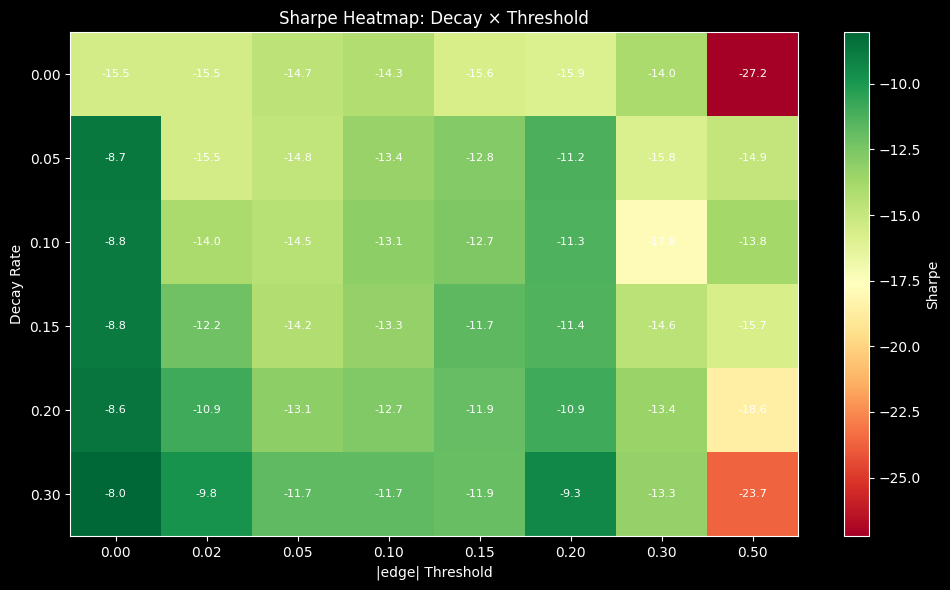


*** BEST OVERALL: decay=0.30 thr=0.00 → Sharpe=-8.04 ***


In [8]:
# ── Cell 8: Experiment 4 — Full Grid Search (decay × threshold) ──────────
# Systematic scan of all promising decay × threshold combinations

print('EXPERIMENT 4: Full Grid — Decay × Threshold')
print(f'{"="*80}')

grid_results = []
decay_vals = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
thr_vals = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]

for decay in decay_vals:
    params = dict(pa_model.params)
    params['pattern_decay_rate'] = decay
    edge = run_pa_batch(params)
    col = f'_tmp_d{int(decay*100):02d}'
    btc_features[col] = edge
    
    for thr in thr_vals:
        r = evaluate_signal_with_threshold(btc_features, col, thr, horizon=1, cost_bps=COST_BPS)
        grid_results.append({'decay': decay, 'threshold': thr, **r})
    
    btc_features.drop(columns=[col], inplace=True)

# Show top 10
grid_sorted = sorted(grid_results, key=lambda x: x['sharpe'], reverse=True)
print(f'\nTop 10 combinations:')
print(f'{"Decay":>6s} {"Thr":>6s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s} {"MaxDD":>8s} {"Trades":>7s} {"Active":>7s}')
print(f'{"-"*62}')
for r in grid_sorted[:10]:
    print(f'{r["decay"]:6.2f} {r["threshold"]:6.2f} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["max_dd"]:8.1%} {r["n_trades"]:7d} {r["active_bars"]:7d}')

# Bottom 5 for context
print(f'\nBottom 5:')
for r in grid_sorted[-5:]:
    print(f'{r["decay"]:6.2f} {r["threshold"]:6.2f} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["max_dd"]:8.1%} {r["n_trades"]:7d} {r["active_bars"]:7d}')

# Heatmap
sharpe_grid = np.full((len(decay_vals), len(thr_vals)), np.nan)
for r in grid_results:
    i = decay_vals.index(r['decay'])
    j = thr_vals.index(r['threshold'])
    sharpe_grid[i, j] = r['sharpe']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sharpe_grid, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(thr_vals)))
ax.set_xticklabels([f'{t:.2f}' for t in thr_vals])
ax.set_yticks(range(len(decay_vals)))
ax.set_yticklabels([f'{d:.2f}' for d in decay_vals])
ax.set_xlabel('|edge| Threshold')
ax.set_ylabel('Decay Rate')
ax.set_title('Sharpe Heatmap: Decay × Threshold')
for i in range(len(decay_vals)):
    for j in range(len(thr_vals)):
        val = sharpe_grid[i, j]
        if not np.isnan(val):
            color = 'black' if val > 0 else 'white'
            ax.text(j, i, f'{val:+.1f}', ha='center', va='center', fontsize=8, color=color)
fig.colorbar(im, label='Sharpe')
plt.tight_layout()
plt.show()

# Store best for later
best_grid = grid_sorted[0]
print(f'\n*** BEST OVERALL: decay={best_grid["decay"]:.2f} thr={best_grid["threshold"]:.2f} → Sharpe={best_grid["sharpe"]:+.2f} ***')

In [9]:
# ── Cell 9: Best PA Variant — Deep Analysis ──────────────────────────────
# Recompute best variant and do full analysis

best_params = dict(pa_model.params)
best_params['pattern_decay_rate'] = best_grid['decay']
best_thr = best_grid['threshold']

btc_features['edge_PA_best'] = run_pa_batch(best_params)

# Apply threshold: zero out signals below threshold
btc_features['edge_PA_filtered'] = btc_features['edge_PA_best'].where(
    btc_features['edge_PA_best'].abs() > best_thr, 0.0
)

print(f'Best PA Config: decay={best_params["pattern_decay_rate"]:.2f}, threshold={best_thr:.2f}')
print(f'{"="*80}')

# Multi-horizon
print(f'\n1. MULTI-HORIZON PERFORMANCE')
print(f'{"Signal":28s} {"H":>3s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s} {"MaxDD":>8s} {"Trades":>7s}')
print('-' * 75)
for label, col in [('PA Filtered', 'edge_PA_filtered'), ('PA Baseline (d=0.3)', 'edge_PA_base'), ('Momentum', 'edge_Momentum')]:
    for h in [1, 4, 12]:
        r = evaluate_signal(btc_features, col, horizon=h, cost_bps=COST_BPS)
        print(f'{label:28s} {h:3d} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%} {r["max_dd"]:8.1%} {r["n_trades"]:7d}')
    print()

# Walk-Forward
print(f'2. WALK-FORWARD (h=1)')
eval_df = btc_features.dropna(subset=['edge_PA_filtered', 'fwd_ret_1']).copy()
train_df, test_df, val_df = split_temporal(eval_df, train=0.6, test=0.2, val=0.2)
print(f'{"Split":8s} {"Bars":>6s} {"Sharpe":>8s} {"HR":>7s} {"CumRet":>9s}')
print('-' * 42)
for sname, sdf in [('Train', train_df), ('Test', test_df), ('Val', val_df)]:
    r = evaluate_signal_with_threshold(sdf, 'edge_PA_best', best_thr, horizon=1, cost_bps=COST_BPS)
    print(f'{sname:8s} {len(sdf):6d} {r["sharpe"]:+8.2f} {r["hit_rate"]:7.1%} {r["cum_ret"]:+8.1%}')

# Per-Regime
print(f'\n3. PER-REGIME SHARPE (h=1)')
print(f'{"Group":18s} {"PA Filt":>8s} {"Momentum":>8s} {"PA wins?":>8s}')
print('-' * 45)
for grp in GROUPS:
    pa_s = mom_s = 0.0
    for sig_col, label in [('edge_PA_filtered', 'pa'), ('edge_Momentum', 'mom')]:
        mask = (btc_features['regime_group'] == grp) & btc_features[sig_col].notna() & btc_features['fwd_ret_1'].notna()
        sub = btc_features[mask]
        d = np.sign(sub[sig_col].values)
        f = sub['fwd_ret_1'].values
        a = d != 0
        if a.sum() > 0:
            sr = (d * f)[a]
            s = (np.mean(sr) / np.std(sr) * math.sqrt(8760)) if np.std(sr) > 0 else 0.0
        else:
            s = 0.0
        if label == 'pa':
            pa_s = s
        else:
            mom_s = s
    better = 'YES' if pa_s > mom_s else 'no'
    print(f'{grp:18s} {pa_s:+8.2f} {mom_s:+8.2f} {better:>8s}')

# Correlation
print(f'\n4. SIGNAL CORRELATION')
corr = btc_features[['edge_PA_filtered', 'edge_Momentum']].dropna()
corr = corr[corr['edge_PA_filtered'] != 0]  # only where PA is active
print(f'  PA vs Momentum: r = {corr["edge_PA_filtered"].corr(corr["edge_Momentum"]):+.4f} ({len(corr)} bars)')

Best PA Config: decay=0.30, threshold=0.00

1. MULTI-HORIZON PERFORMANCE
Signal                         H   Sharpe      HR    CumRet    MaxDD  Trades
---------------------------------------------------------------------------
PA Filtered                    1    -8.04   43.6%   -84.3%   -84.8%     905
PA Filtered                    4    -5.39   46.1%   -92.7%   -93.6%     905
PA Filtered                   12    -3.93   47.2%   -97.3%   -97.8%     905

PA Baseline (d=0.3)            1    -8.04   43.6%   -84.3%   -84.8%     905
PA Baseline (d=0.3)            4    -5.39   46.1%   -92.7%   -93.6%     905
PA Baseline (d=0.3)           12    -3.93   47.2%   -97.3%   -97.8%     905

Momentum                       1    +1.22   44.5%    +3.6%   -11.1%      39
Momentum                       4    +0.21   43.8%    -2.3%   -37.1%      39
Momentum                      12    +0.01   47.0%    -8.7%   -54.9%      39

2. WALK-FORWARD (h=1)
Split      Bars   Sharpe      HR    CumRet
----------------------

BENCHMARK COMPARISON (h=1, 10bps cost)

Strategy                   Sharpe    CumRet    MaxDD  Trades
------------------------------------------------------------
PA Filtered                 -8.04   -84.3%   -84.8%     905
Momentum Solo               +1.22    +3.6%   -11.1%      39
BTC Buy & Hold              -0.50   -14.9%   -35.6%     N/A
S&P 500 B&H (approx)        +0.67    +5.1%      N/A     N/A


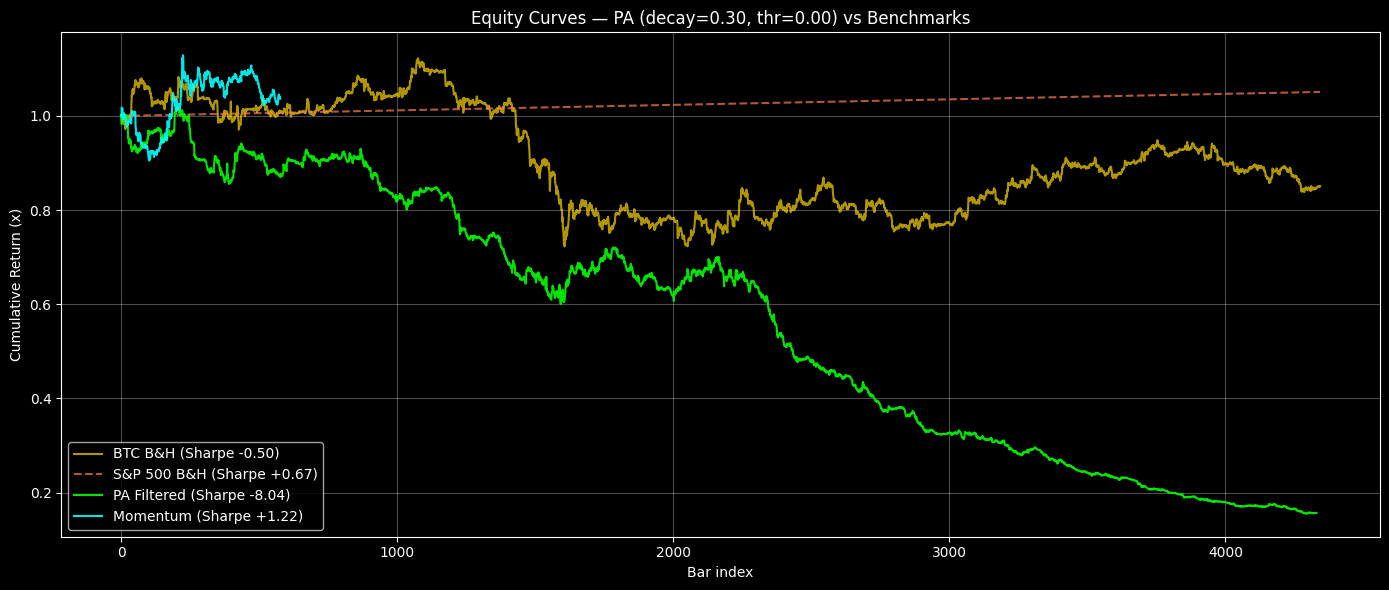

In [10]:
# ── Cell 10: Benchmark Comparison & Equity Curves ─────────────────────────

print(f'{"="*80}')
print('BENCHMARK COMPARISON (h=1, 10bps cost)')
print(f'{"="*80}')

pa_r = evaluate_signal(btc_features, 'edge_PA_filtered', horizon=1, cost_bps=COST_BPS)
mom_r = evaluate_signal(btc_features, 'edge_Momentum', horizon=1, cost_bps=COST_BPS)

print(f'\n{"Strategy":24s} {"Sharpe":>8s} {"CumRet":>9s} {"MaxDD":>8s} {"Trades":>7s}')
print('-' * 60)
print(f'{"PA Filtered":24s} {pa_r["sharpe"]:+8.2f} {pa_r["cum_ret"]:+8.1%} {pa_r["max_dd"]:8.1%} {pa_r["n_trades"]:7d}')
print(f'{"Momentum Solo":24s} {mom_r["sharpe"]:+8.2f} {mom_r["cum_ret"]:+8.1%} {mom_r["max_dd"]:8.1%} {mom_r["n_trades"]:7d}')
print(f'{"BTC Buy & Hold":24s} {bh_sharpe:+8.2f} {bh_cum_ret:+8.1%} {bh_dd:8.1%} {"N/A":>7s}')
print(f'{"S&P 500 B&H (approx)":24s} {sp_sharpe:+8.2f} {sp_cum_ret:+8.1%} {"N/A":>8s} {"N/A":>7s}')

# Equity curves
fig, ax = plt.subplots(figsize=(14, 6))

# BTC Buy & Hold
bh_rets = btc_features['bh_ret'].dropna().values
ax.plot(np.cumprod(1 + bh_rets), label=f'BTC B&H (Sharpe {bh_sharpe:+.2f})', color='gold', alpha=0.7)

# S&P reference line
sp_line = np.linspace(1.0, 1.0 + sp_cum_ret, len(bh_rets))
ax.plot(sp_line, label=f'S&P 500 B&H (Sharpe {sp_sharpe:+.2f})', color='coral', linestyle='--', alpha=0.7)

# PA Filtered
for label, col, color in [('PA Filtered', 'edge_PA_filtered', 'lime'),
                           ('Momentum', 'edge_Momentum', 'cyan')]:
    mask = btc_features[col].notna() & btc_features['fwd_ret_1'].notna() & (btc_features[col] != 0)
    sub = btc_features[mask]
    d = np.sign(sub[col].values)
    f = sub['fwd_ret_1'].values
    sr = d * f
    dc = np.diff(np.concatenate([[0.0], d]))
    tc = np.abs(dc) * (COST_BPS / 10_000.0)
    sr -= tc[:len(sr)]
    cum = np.cumprod(1 + sr)
    r = evaluate_signal(btc_features, col, horizon=1, cost_bps=COST_BPS)
    ax.plot(cum, label=f'{label} (Sharpe {r["sharpe"]:+.2f})', color=color, alpha=0.9)

ax.set_title(f'Equity Curves — PA (decay={best_params["pattern_decay_rate"]:.2f}, thr={best_thr:.2f}) vs Benchmarks')
ax.set_ylabel('Cumulative Return (x)')
ax.set_xlabel('Bar index')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ── Cell 11: Final Verdict ────────────────────────────────────────────────

pa_r = evaluate_signal(btc_features, 'edge_PA_filtered', horizon=1, cost_bps=COST_BPS)

beats_btc_bh = pa_r['sharpe'] > bh_sharpe
beats_sp_bh = pa_r['sharpe'] > sp_sharpe
beats_momentum = pa_r['sharpe'] > mom_r['sharpe']
positive_sharpe = pa_r['sharpe'] > 0

# Walk-forward stability check
eval_df = btc_features.dropna(subset=['edge_PA_filtered', 'fwd_ret_1']).copy()
train_df, test_df, val_df = split_temporal(eval_df, train=0.6, test=0.2, val=0.2)
wf_train = evaluate_signal_with_threshold(train_df, 'edge_PA_best', best_thr, horizon=1, cost_bps=COST_BPS)
wf_test = evaluate_signal_with_threshold(test_df, 'edge_PA_best', best_thr, horizon=1, cost_bps=COST_BPS)
wf_val = evaluate_signal_with_threshold(val_df, 'edge_PA_best', best_thr, horizon=1, cost_bps=COST_BPS)
wf_stable = wf_test['sharpe'] > 0 and wf_val['sharpe'] > 0

print(f'{"="*70}')
print('FINAL VERDICT — PriceAction Ensemble')
print(f'{"="*70}')
print(f'\nBest config: decay={best_params["pattern_decay_rate"]:.2f}, threshold={best_thr:.2f}')
print(f'\nCriteria:')
print(f'  [{"+" if positive_sharpe else "X"}] Positive Sharpe:     {pa_r["sharpe"]:+.2f}')
print(f'  [{"+" if beats_btc_bh else "X"}] Beats BTC B&H:       {pa_r["sharpe"]:+.2f} vs {bh_sharpe:+.2f}')
print(f'  [{"+" if beats_sp_bh else "X"}] Beats S&P B&H:       {pa_r["sharpe"]:+.2f} vs {sp_sharpe:+.2f}')
print(f'  [{"+" if beats_momentum else "X"}] Beats Momentum:      {pa_r["sharpe"]:+.2f} vs {mom_r["sharpe"]:+.2f}')
print(f'  [{"+" if wf_stable else "X"}] Walk-Forward Stable:  Train={wf_train["sharpe"]:+.2f} Test={wf_test["sharpe"]:+.2f} Val={wf_val["sharpe"]:+.2f}')

go_count = sum([positive_sharpe, beats_btc_bh, beats_sp_bh, wf_stable])
if go_count >= 3:
    verdict = 'GO'
    reasoning = 'PA clears at least 3/4 benchmark criteria.'
elif go_count >= 2:
    verdict = 'CONDITIONAL GO'
    reasoning = 'PA passes some benchmarks — consider regime-specific deployment or further tuning.'
elif positive_sharpe:
    verdict = 'WEAK — NEEDS MORE WORK'
    reasoning = 'Positive Sharpe but fails benchmark tests. Not deployment-ready.'
else:
    verdict = 'NO-GO'
    reasoning = 'Negative Sharpe even after filtering. PA kernels do not generate alpha on BTC 1h.'

print(f'\n  >>> {verdict} <<<')
print(f'  {reasoning}')

# Summary stats
print(f'\n  Total configs tested: {len(grid_results)}')
print(f'  Configs with Sharpe > 0: {sum(1 for r in grid_results if r["sharpe"] > 0)}')
print(f'  Configs beating BTC B&H: {sum(1 for r in grid_results if r["sharpe"] > bh_sharpe)}')
print(f'  Configs beating S&P B&H: {sum(1 for r in grid_results if r["sharpe"] > sp_sharpe)}')

FINAL VERDICT — PriceAction Ensemble

Best config: decay=0.30, threshold=0.00

Criteria:
  [X] Positive Sharpe:     -8.04
  [X] Beats BTC B&H:       -8.04 vs -0.50
  [X] Beats S&P B&H:       -8.04 vs +0.67
  [X] Beats Momentum:      -8.04 vs +1.22
  [X] Walk-Forward Stable:  Train=-5.11 Test=-14.37 Val=-14.71

  >>> NO-GO <<<
  Negative Sharpe even after filtering. PA kernels do not generate alpha on BTC 1h.

  Total configs tested: 48
  Configs with Sharpe > 0: 0
  Configs beating BTC B&H: 0
  Configs beating S&P B&H: 0


---
# CAKEUSDT 30m — Taker Buy Ratio & Breakout Analysis

**Thesis:** Taker buy ratio (taker_buy_base / volume) measures aggressive buyer dominance. During breakouts, we expect TFI to spike BEFORE or AT the move — confirming institutional accumulation.

**Data:** CAKEUSDT 30m, Jan 2026 – May 2026

In [12]:
# ── Fetch CAKEUSDT 30m with taker columns ────────────────────────
import time

_ALL_COLS = [
    'timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
    'quote_vol', 'trades', 'taker_buy_base', 'taker_buy_quote', 'ignore',
]

def fetch_full(symbol, interval, start_date, end_date):
    start_ms = int(datetime.strptime(start_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    end_ms = int(datetime.strptime(end_date, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)
    all_rows = []
    cursor = start_ms
    while cursor < end_ms:
        raw = client.klines(symbol, interval, startTime=cursor, endTime=end_ms, limit=1500)
        if not raw:
            break
        all_rows.extend(raw)
        cursor = int(raw[-1][6]) + 1
        if len(raw) < 1500:
            break
        time.sleep(0.15)
    df = pd.DataFrame(all_rows, columns=_ALL_COLS)
    for c in ['open','high','low','close','volume','taker_buy_base','taker_buy_quote','quote_vol']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', utc=True)
    df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    print(f'{symbol} {interval}: {len(df)} bars  [{df.timestamp.iloc[0]} → {df.timestamp.iloc[-1]}]')
    return df

cake = fetch_full('CAKEUSDT', '30m', '2026-01-01', '2026-06-01')

# Compute TFI (Taker Flow Imbalance)
cake['tfi_raw'] = cake['taker_buy_base'] / cake['volume'].replace(0, np.nan)
cake['tfi'] = cake['tfi_raw'].ewm(span=5, adjust=False).mean()
cake['taker_sell'] = cake['volume'] - cake['taker_buy_base']
cake['tfi_net'] = (cake['taker_buy_base'] - cake['taker_sell']) / cake['volume'].replace(0, np.nan)
cake['tfi_net_smooth'] = cake['tfi_net'].ewm(span=5, adjust=False).mean()

# Z-score
roll_mean = cake['tfi'].rolling(200, min_periods=50).mean()
roll_std = cake['tfi'].rolling(200, min_periods=50).std()
cake['tfi_zscore'] = (cake['tfi'] - roll_mean) / roll_std.replace(0, np.nan)

# ATR
cake['tr'] = np.maximum(
    cake['high'] - cake['low'],
    np.maximum(abs(cake['high'] - cake['close'].shift(1)),
               abs(cake['low'] - cake['close'].shift(1)))
)
cake['ATR'] = cake['tr'].ewm(span=14, adjust=False).mean()

# Forward returns
for h in [1, 4, 8, 24, 48]:
    cake[f'fwd_{h}'] = cake['close'].pct_change(h).shift(-h)

cake['ret'] = cake['close'].pct_change()

print(f'\nTFI Distribution:')
print(f'  Mean: {cake["tfi"].mean():.4f} (0.50 = neutral)')
print(f'  Range: [{cake["tfi"].min():.4f}, {cake["tfi"].max():.4f}]')
print(f'  Median: {cake["tfi"].median():.4f}')
print(f'  Std: {cake["tfi"].std():.4f}')
print(f'\nTFI Z-score stats:')
print(cake['tfi_zscore'].describe())

CAKEUSDT 30m: 7228 bars  [2026-01-01 00:00:00+00:00 → 2026-05-31 13:30:00+00:00]

TFI Distribution:
  Mean: 0.4917 (0.50 = neutral)
  Range: [0.2930, 0.6704]
  Median: 0.4920
  Std: 0.0500

TFI Z-score stats:
count   7179.0000
mean      -0.0006
std        1.0163
min       -3.4176
25%       -0.6739
50%       -0.0002
75%        0.6834
max        3.4613
Name: tfi_zscore, dtype: float64


In [13]:
# ── TFI vs Forward Returns — Correlation ─────────────────────────
print("=" * 70)
print("CAKEUSDT 30m: TFI PREDICTIVE POWER")
print("=" * 70)

print("\n▸ TFI vs Forward Returns (Pearson r):")
for tfi_col in ['tfi', 'tfi_net_smooth', 'tfi_zscore']:
    for fwd_col in ['fwd_1', 'fwd_4', 'fwd_8', 'fwd_24', 'fwd_48']:
        corr = cake[[tfi_col, fwd_col]].dropna().corr().iloc[0, 1]
        marker = ' ◀' if abs(corr) > 0.03 else ''
        print(f"  {tfi_col:18s} vs {fwd_col}: r={corr:+.4f}{marker}")

# Conditional returns by TFI quintile
print("\n▸ Forward 24-bar Return by TFI Quintile:")
cake['tfi_q'] = pd.qcut(cake['tfi'].dropna(), 5, labels=['Q1_sell','Q2','Q3','Q4','Q5_buy'])
q_stats = cake.groupby('tfi_q', observed=True)['fwd_24'].agg(['mean','std','count'])
q_stats['mean_pct'] = q_stats['mean'] * 100
q_stats['wr'] = cake.groupby('tfi_q', observed=True)['fwd_24'].apply(lambda x: (x > 0).mean()) * 100
print(q_stats[['mean_pct','wr','count']].to_string())

# Extreme TFI z-scores
print("\n▸ Extreme TFI Z-score Conditional Returns:")
for z_thresh in [1.0, 1.5, 2.0]:
    high_z = cake[cake['tfi_zscore'] > z_thresh]
    low_z = cake[cake['tfi_zscore'] < -z_thresh]
    if len(high_z) > 5:
        print(f"  z > +{z_thresh:.1f} ({len(high_z)} bars): fwd_24 mean = {high_z['fwd_24'].mean()*100:+.3f}%, WR = {(high_z['fwd_24']>0).mean()*100:.1f}%")
    if len(low_z) > 5:
        print(f"  z < -{z_thresh:.1f} ({len(low_z)} bars): fwd_24 mean = {low_z['fwd_24'].mean()*100:+.3f}%, WR = {(low_z['fwd_24']>0).mean()*100:.1f}%")

CAKEUSDT 30m: TFI PREDICTIVE POWER

▸ TFI vs Forward Returns (Pearson r):
  tfi                vs fwd_1: r=+0.0172
  tfi                vs fwd_4: r=+0.0167
  tfi                vs fwd_8: r=+0.0200
  tfi                vs fwd_24: r=-0.0050
  tfi                vs fwd_48: r=+0.0077
  tfi_net_smooth     vs fwd_1: r=+0.0172
  tfi_net_smooth     vs fwd_4: r=+0.0167
  tfi_net_smooth     vs fwd_8: r=+0.0200
  tfi_net_smooth     vs fwd_24: r=-0.0050
  tfi_net_smooth     vs fwd_48: r=+0.0077
  tfi_zscore         vs fwd_1: r=+0.0142
  tfi_zscore         vs fwd_4: r=+0.0141
  tfi_zscore         vs fwd_8: r=+0.0173
  tfi_zscore         vs fwd_24: r=-0.0093
  tfi_zscore         vs fwd_48: r=+0.0033

▸ Forward 24-bar Return by TFI Quintile:
         mean_pct      wr  count
tfi_q                           
Q1_sell   -0.0553 48.6860   1442
Q2        -0.0529 46.2284   1438
Q3        -0.0620 46.6113   1440
Q4        -0.0509 47.6817   1440
Q5_buy    -0.0656 46.9571   1444

▸ Extreme TFI Z-score Condition

Breakout detected: 2026-05-30 18:30:00+00:00 | Price: 1.5096 | 24h move: +12.23%


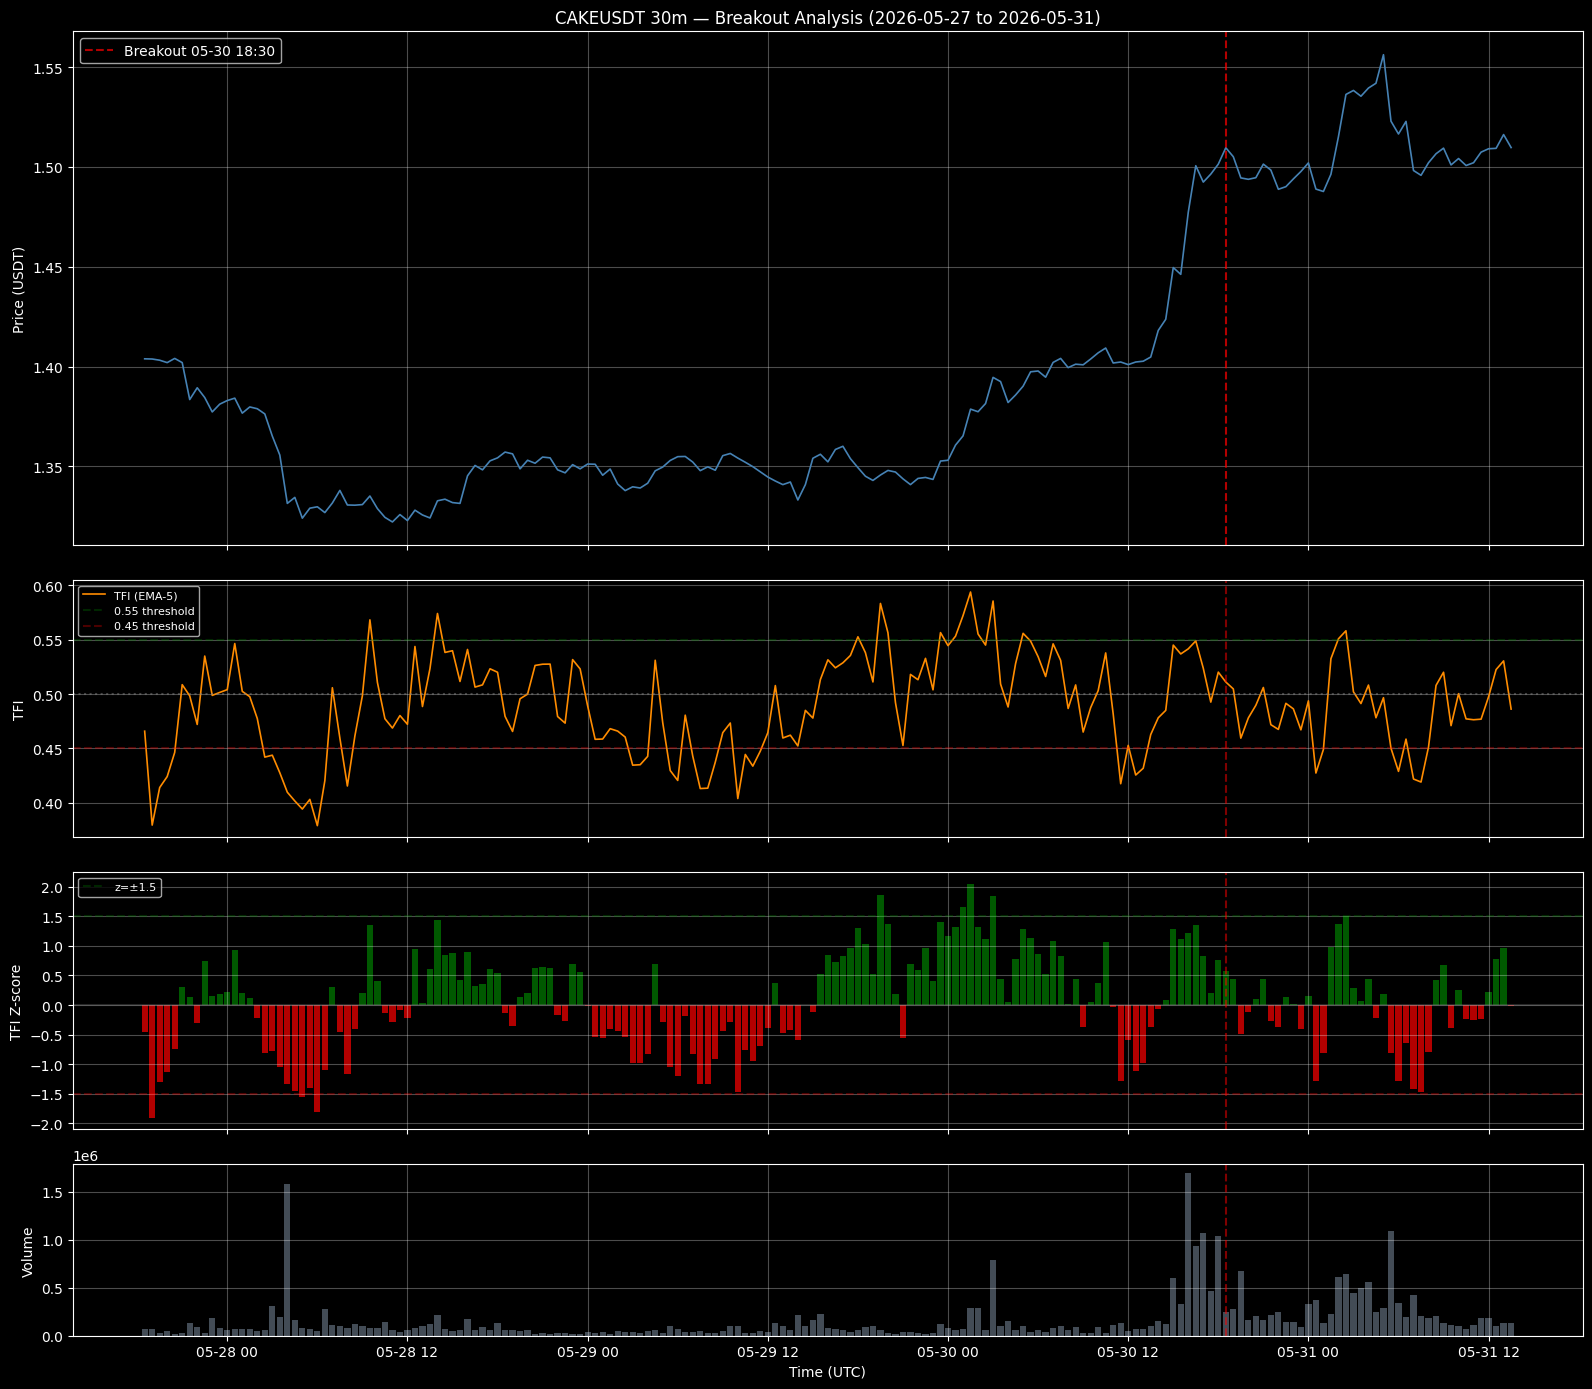


▸ TFI 12h BEFORE breakout:
  Mean TFI:     0.4969
  Max TFI:      0.5489
  Mean Z-score: +0.27
  Max Z-score:  +1.34
  Bars with z>1: 6 / 24

▸ TFI 12h AFTER breakout:
  Mean TFI:     0.4875
  Max TFI:      0.5582
  Mean Z-score: +0.03
  Max Z-score:  +1.50

▸ Full-sample average TFI: 0.4917
  Pre-breakout deviation from mean: +0.0052 (+0.10σ)


In [14]:
# ── BREAKOUT ZOOM: Price + TFI around the recent breakout ────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Find the breakout: biggest single-day move in the last 2 weeks
recent = cake[cake['timestamp'] >= '2026-05-15'].copy()
recent['daily_ret'] = recent['close'].pct_change(48)  # ~48 x 30min = 24h
breakout_idx = recent['daily_ret'].idxmax()
breakout_ts = recent.loc[breakout_idx, 'timestamp']
breakout_price = recent.loc[breakout_idx, 'close']
print(f"Breakout detected: {breakout_ts} | Price: {breakout_price:.4f} | 24h move: {recent.loc[breakout_idx, 'daily_ret']*100:+.2f}%")

# Window: 3 days before to 1 day after breakout
window_start = breakout_ts - pd.Timedelta(days=3)
window_end = breakout_ts + pd.Timedelta(days=1)
zoom = cake[(cake['timestamp'] >= window_start) & (cake['timestamp'] <= window_end)].copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.5, 1.5, 1]})

# Panel 1: Price with breakout marker
ax1 = axes[0]
ax1.plot(zoom['timestamp'], zoom['close'], linewidth=1.2, color='steelblue')
ax1.axvline(breakout_ts, color='red', ls='--', alpha=0.7, label=f'Breakout {breakout_ts.strftime("%m-%d %H:%M")}')
ax1.set_ylabel('Price (USDT)')
ax1.set_title(f'CAKEUSDT 30m — Breakout Analysis ({window_start.date()} to {window_end.date()})')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: TFI (smoothed)
ax2 = axes[1]
ax2.plot(zoom['timestamp'], zoom['tfi'], linewidth=1.2, color='darkorange', label='TFI (EMA-5)')
ax2.axhline(0.50, color='gray', ls=':', alpha=0.5)
ax2.axhline(0.55, color='green', ls='--', alpha=0.3, label='0.55 threshold')
ax2.axhline(0.45, color='red', ls='--', alpha=0.3, label='0.45 threshold')
ax2.axvline(breakout_ts, color='red', ls='--', alpha=0.5)
ax2.set_ylabel('TFI')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(alpha=0.3)

# Panel 3: TFI Z-score
ax3 = axes[2]
colors = ['green' if z > 0 else 'red' for z in zoom['tfi_zscore'].fillna(0)]
ax3.bar(zoom['timestamp'], zoom['tfi_zscore'].fillna(0), width=pd.Timedelta(minutes=25),
        color=colors, alpha=0.7)
ax3.axhline(0, color='gray', ls='-', alpha=0.3)
ax3.axhline(1.5, color='green', ls='--', alpha=0.3, label='z=±1.5')
ax3.axhline(-1.5, color='red', ls='--', alpha=0.3)
ax3.axvline(breakout_ts, color='red', ls='--', alpha=0.5)
ax3.set_ylabel('TFI Z-score')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(alpha=0.3)

# Panel 4: Volume
ax4 = axes[3]
ax4.bar(zoom['timestamp'], zoom['volume'], width=pd.Timedelta(minutes=25),
        color='slategray', alpha=0.6)
ax4.axvline(breakout_ts, color='red', ls='--', alpha=0.5)
ax4.set_ylabel('Volume')
ax4.set_xlabel('Time (UTC)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Pre-breakout TFI behavior (12h before breakout)
pre_window = cake[(cake['timestamp'] >= breakout_ts - pd.Timedelta(hours=12)) & 
                   (cake['timestamp'] < breakout_ts)]
post_window = cake[(cake['timestamp'] >= breakout_ts) & 
                    (cake['timestamp'] < breakout_ts + pd.Timedelta(hours=12))]

print(f'\n▸ TFI 12h BEFORE breakout:')
print(f'  Mean TFI:     {pre_window["tfi"].mean():.4f}')
print(f'  Max TFI:      {pre_window["tfi"].max():.4f}')
print(f'  Mean Z-score: {pre_window["tfi_zscore"].mean():+.2f}')
print(f'  Max Z-score:  {pre_window["tfi_zscore"].max():+.2f}')
print(f'  Bars with z>1: {(pre_window["tfi_zscore"] > 1).sum()} / {len(pre_window)}')

print(f'\n▸ TFI 12h AFTER breakout:')
print(f'  Mean TFI:     {post_window["tfi"].mean():.4f}')
print(f'  Max TFI:      {post_window["tfi"].max():.4f}')
print(f'  Mean Z-score: {post_window["tfi_zscore"].mean():+.2f}')
print(f'  Max Z-score:  {post_window["tfi_zscore"].max():+.2f}')

print(f'\n▸ Full-sample average TFI: {cake["tfi"].mean():.4f}')
pre_diff = pre_window["tfi"].mean() - cake["tfi"].mean()
print(f'  Pre-breakout deviation from mean: {pre_diff:+.4f} ({pre_diff/cake["tfi"].std():+.2f}σ)')

CAKEUSDT 30m: TFI BACKTEST SWEEP

▸ Threshold-based:
  tfi>0.52: 407 trades | WR=48.9% | Avg=+0.177% | Total=+72.15% | PF=1.42
  tfi>0.53: 390 trades | WR=48.2% | Avg=+0.153% | Total=+59.55% | PF=1.41
  tfi>0.55: 345 trades | WR=45.5% | Avg=+0.081% | Total=+27.94% | PF=1.39
  tfi>0.57: 273 trades | WR=48.0% | Avg=+0.146% | Total=+39.73% | PF=1.43
  tfi>0.60: 150 trades | WR=45.3% | Avg=+0.017% | Total=+2.60% | PF=1.25

▸ Z-score based:
  z>0.50: 402 trades | WR=50.2% | Avg=+0.199% | Total=+79.82% | PF=1.39
  z>0.75: 390 trades | WR=45.9% | Avg=+0.093% | Total=+36.40% | PF=1.39
  z>1.00: 348 trades | WR=46.6% | Avg=+0.088% | Total=+30.54% | PF=1.34
  z>1.25: 314 trades | WR=48.4% | Avg=+0.129% | Total=+40.46% | PF=1.34
  z>1.50: 261 trades | WR=48.7% | Avg=+0.139% | Total=+36.16% | PF=1.36
  z>2.00: 144 trades | WR=42.4% | Avg=-0.051% | Total=-7.38% | PF=1.22

▸ Equity curve for z>1.0:


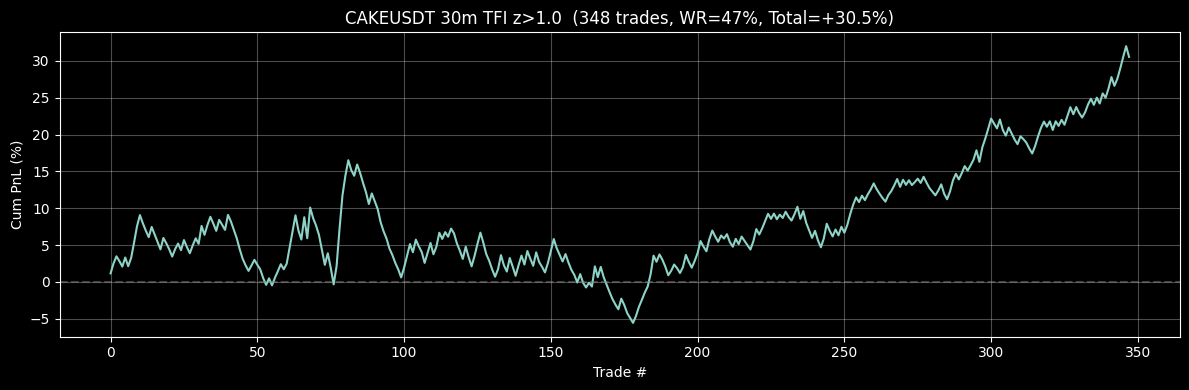

In [15]:
# ── TFI Signal Backtest on CAKEUSDT 30m ──────────────────────────
def backtest_tfi(
    df, use_zscore=False, tfi_long=0.55, tfi_short=0.45,
    zscore_long=1.0, zscore_short=-1.0,
    atr_tp=2.0, atr_sl=1.5, cooldown=6,
):
    closes = df['close'].values
    highs = df['high'].values
    lows = df['low'].values
    atr = df['ATR'].values
    tfi = df['tfi_zscore'].values if use_zscore else df['tfi'].values
    t_long = zscore_long if use_zscore else tfi_long
    t_short = zscore_short if use_zscore else tfi_short

    trades = []
    pos = 0
    entry_px = tp_px = sl_px = 0.0
    entry_bar = 0
    last_exit = -cooldown

    for i in range(100, len(df)):
        if np.isnan(atr[i]) or np.isnan(tfi[i]):
            continue
        if pos == 1:
            if lows[i] <= sl_px:
                trades.append({'bar': entry_bar, 'exit': i, 'dir': 'L',
                               'pnl': (sl_px - entry_px)/entry_px*100, 'r': 'SL',
                               'entry_ts': df.iloc[entry_bar]['timestamp'],
                               'exit_ts': df.iloc[i]['timestamp']})
                pos = 0; last_exit = i
            elif highs[i] >= tp_px:
                trades.append({'bar': entry_bar, 'exit': i, 'dir': 'L',
                               'pnl': (tp_px - entry_px)/entry_px*100, 'r': 'TP',
                               'entry_ts': df.iloc[entry_bar]['timestamp'],
                               'exit_ts': df.iloc[i]['timestamp']})
                pos = 0; last_exit = i
        elif pos == -1:
            if highs[i] >= sl_px:
                trades.append({'bar': entry_bar, 'exit': i, 'dir': 'S',
                               'pnl': (entry_px - sl_px)/entry_px*100, 'r': 'SL',
                               'entry_ts': df.iloc[entry_bar]['timestamp'],
                               'exit_ts': df.iloc[i]['timestamp']})
                pos = 0; last_exit = i
            elif lows[i] <= tp_px:
                trades.append({'bar': entry_bar, 'exit': i, 'dir': 'S',
                               'pnl': (entry_px - tp_px)/entry_px*100, 'r': 'TP',
                               'entry_ts': df.iloc[entry_bar]['timestamp'],
                               'exit_ts': df.iloc[i]['timestamp']})
                pos = 0; last_exit = i
        if pos == 0 and (i - last_exit) >= cooldown:
            if tfi[i] > t_long:
                pos = 1; entry_px = closes[i]
                tp_px = entry_px + atr[i]*atr_tp; sl_px = entry_px - atr[i]*atr_sl; entry_bar = i
            elif tfi[i] < t_short:
                pos = -1; entry_px = closes[i]
                tp_px = entry_px - atr[i]*atr_tp; sl_px = entry_px + atr[i]*atr_sl; entry_bar = i
    return pd.DataFrame(trades)

def print_bt(label, trades):
    if trades.empty:
        print(f"  {label}: No trades"); return
    n = len(trades)
    wr = (trades['pnl'] > 0).mean() * 100
    avg = trades['pnl'].mean()
    tot = trades['pnl'].sum()
    aw = trades.loc[trades['pnl']>0, 'pnl'].mean() if (trades['pnl']>0).any() else 0
    al = trades.loc[trades['pnl']<=0, 'pnl'].mean() if (trades['pnl']<=0).any() else 0
    pf = abs(aw/al) if al != 0 else float('inf')
    print(f"  {label}: {n} trades | WR={wr:.1f}% | Avg={avg:+.3f}% | Total={tot:+.2f}% | PF={pf:.2f}")

print("=" * 70)
print("CAKEUSDT 30m: TFI BACKTEST SWEEP")
print("=" * 70)

# Threshold-based sweep
print("\n▸ Threshold-based:")
for thresh in [0.52, 0.53, 0.55, 0.57, 0.60]:
    t = backtest_tfi(cake, tfi_long=thresh, tfi_short=1-thresh)
    print_bt(f'tfi>{thresh:.2f}', t)

# Z-score sweep
print("\n▸ Z-score based:")
for z in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    t = backtest_tfi(cake, use_zscore=True, zscore_long=z, zscore_short=-z)
    print_bt(f'z>{z:.2f}', t)

# Best config equity curve
print("\n▸ Equity curve for z>1.0:")
best_trades = backtest_tfi(cake, use_zscore=True, zscore_long=1.0, zscore_short=-1.0)
if not best_trades.empty:
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    ax.plot(best_trades['pnl'].cumsum().values, linewidth=1.5)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    n = len(best_trades)
    wr = (best_trades['pnl']>0).mean()*100
    ax.set_title(f'CAKEUSDT 30m TFI z>1.0  ({n} trades, WR={wr:.0f}%, Total={best_trades["pnl"].sum():+.1f}%)')
    ax.set_xlabel('Trade #'); ax.set_ylabel('Cum PnL (%)')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [16]:
# ── CAKEUSDT 30m: TFI VERDICT ────────────────────────────────────
print("=" * 70)
print("CAKEUSDT 30m — TFI COMPOSITE VERDICT")
print("=" * 70)

# Criteria
best_z = backtest_tfi(cake, use_zscore=True, zscore_long=1.0, zscore_short=-1.0)
best_thresh = backtest_tfi(cake, tfi_long=0.55, tfi_short=0.45)

checks = {}

# 1. Correlation
corr_8 = cake[['tfi_zscore','fwd_8']].dropna().corr().iloc[0,1]
corr_24 = cake[['tfi_zscore','fwd_24']].dropna().corr().iloc[0,1]
checks['correlation'] = abs(corr_8) > 0.03 or abs(corr_24) > 0.03
print(f'\n1. Correlation: r_8={corr_8:+.4f}, r_24={corr_24:+.4f}  → {"GO" if checks["correlation"] else "NO-GO"}')

# 2. Monotonic quintile spread
q_means = cake.groupby('tfi_q', observed=True)['fwd_24'].mean()
spread = q_means.iloc[-1] - q_means.iloc[0]
checks['quintile_spread'] = spread > 0
print(f'2. Quintile spread Q5-Q1: {spread*100:+.4f}%  → {"GO" if checks["quintile_spread"] else "NO-GO"}')

# 3. Backtest WR
if not best_z.empty:
    wr = (best_z['pnl'] > 0).mean() * 100
    checks['backtest_wr'] = wr > 50
    print(f'3. Best z-score WR: {wr:.1f}%  → {"GO" if checks["backtest_wr"] else "NO-GO"}')
else:
    checks['backtest_wr'] = False
    print(f'3. Best z-score WR: No trades → NO-GO')

# 4. Positive total PnL
if not best_z.empty:
    total = best_z['pnl'].sum()
    checks['positive_pnl'] = total > 0
    print(f'4. Total PnL (z>1.0): {total:+.2f}%  → {"GO" if checks["positive_pnl"] else "NO-GO"}')
else:
    checks['positive_pnl'] = False
    print(f'4. Total PnL: No trades → NO-GO')

# 5. Signal density (>5 signals per month)
n_months = (cake['timestamp'].iloc[-1] - cake['timestamp'].iloc[0]).days / 30
if not best_z.empty:
    density = len(best_z) / n_months
    checks['signal_density'] = density > 5
    print(f'5. Signal density: {density:.1f}/month  → {"GO" if checks["signal_density"] else "NO-GO"}')
else:
    checks['signal_density'] = False
    print(f'5. Signal density: No trades → NO-GO')

# 6. Breakout detection (did TFI spike before/during breakout?)
if 'pre_window' in dir() and len(pre_window) > 0:
    pre_z_max = pre_window['tfi_zscore'].max()
    checks['breakout_signal'] = pre_z_max > 1.0
    print(f'6. Pre-breakout TFI z-max: {pre_z_max:+.2f}  → {"GO" if checks["breakout_signal"] else "NO-GO"}')

go_count = sum(checks.values())
total_checks = len(checks)
verdict = 'GO' if go_count >= 4 else 'CONDITIONAL GO' if go_count >= 3 else 'NO-GO'

print(f'\n{"=" * 70}')
print(f'VERDICT: {verdict}  ({go_count}/{total_checks} checks passed)')
print(f'{"=" * 70}')

CAKEUSDT 30m — TFI COMPOSITE VERDICT

1. Correlation: r_8=+0.0173, r_24=-0.0093  → NO-GO
2. Quintile spread Q5-Q1: -0.0104%  → NO-GO
3. Best z-score WR: 46.6%  → NO-GO
4. Total PnL (z>1.0): +30.54%  → GO
5. Signal density: 69.6/month  → GO
6. Pre-breakout TFI z-max: +1.34  → GO

VERDICT: CONDITIONAL GO  (3/6 checks passed)
